# DSC 291: Learning Theory - PA6

**James Doan**

## Part A: Boosting Sparse Linear Predictors and the $\ell_1$ Margin

### 1. From sparse margin to a weak coordinate.

**Proof:**

We are given that $y \langle w^\star, \phi(x) \rangle \ge 1$ for all $(x,y)$ in the support of $Q$. We can rewrite the inner product as:
$$\langle w^\star, \phi(x) \rangle = \sum_{j=1}^d w^\star_j \phi_j(x) = \sum_{j=1}^d |w^\star_j| \operatorname{sign}(w^\star_j) \phi_j(x) = \sum_{j=1}^d |w^\star_j| b_{j, \operatorname{sign}(w^\star_j)}(x)$$

Let $W = \lVert w^\star \rVert_1 = \sum_{j=1}^d |w^\star_j|$. Then $\frac{1}{W} \langle w^\star, \phi(x) \rangle = \sum_{j=1}^d \frac{|w^\star_j|}{W} b_{j, \operatorname{sign}(w^\star_j)}(x)$.
This is a convex combination of predictors in $\mathcal{B}$. Taking the expectation over $Q$:
$$\mathbb{E}_Q \left[ y \frac{\langle w^\star, \phi(x) \rangle}{W} \right] \ge \frac{1}{W}$$

By linearity of expectation:
$$\sum_{j=1}^d \frac{|w^\star_j|}{W} \mathbb{E}_Q [y b_{j, \operatorname{sign}(w^\star_j)}(x)] \ge \frac{1}{W}$$

Since this is a convex combination of expectations, there must exist at least one $j$ and $\sigma = \operatorname{sign}(w^\star_j)$ such that:
$$\mathbb{E}_Q [y b_{j, \sigma}(x)] \ge \frac{1}{W} = \frac{1}{\lVert w^\star \rVert_1}$$

The edge of a predictor $b$ is $\frac{1}{2} - L_Q(b) = \frac{1}{2} \mathbb{E}_Q [y b(x)]$. Thus, for this $b_{j,\sigma}$, we have:
$$\frac{1}{2} - L_Q(b_{j,\sigma}) \ge \frac{1}{2 \lVert w^\star \rVert_1} \implies L_Q(b_{j,\sigma}) \le \frac{1}{2} - \frac{1}{2 \lVert w^\star \rVert_1}$$

Since $w^\star$ is $s$-sparse and $\lVert w^\star \rVert_\infty \le B$, we have $\lVert w^\star \rVert_1 \le s \lVert w^\star \rVert_\infty \le sB$. Therefore:
$$L_Q(b_{j,\sigma}) \le \frac{1}{2} - \frac{1}{2sB}$$

**$O(nd)$ Weighted ERM Weak Learner:**
Given weighted examples $(x_i, y_i, D_i)_{i=1}^n$, the weighted error of a predictor $b$ is $L_D(b) = \frac{1}{2} - \frac{1}{2} \sum_{i=1}^n D_i y_i b(x_i)$.
To minimize $L_D(b)$ over $b \in \mathcal{B}$, we need to maximize the signed correlation $\sum_{i=1}^n D_i y_i b(x_i)$ (Lemma A.2).
The algorithm computes the signed correlation for each of the $d$ features: $C_j = \sum_{i=1}^n D_i y_i \phi_j(x_i)$. This takes $O(nd)$ time.
Then it finds $j^\star = \arg\max_j |C_j|$ and sets $\sigma^\star = \operatorname{sign}(C_{j^\star})$.
The returned predictor is $b_{j^\star, \sigma^\star}(x) = \sigma^\star \phi_{j^\star}(x)$. Finding the maximum takes $O(d)$ time, so the total time is $O(nd)$.

### 2. Boosting guarantee and comparison with sparse ERM.

**Proof:**

By AdaBoost's training error bound (Freund and Schapire), if the weak learner guarantees an edge $\gamma_t \ge \gamma = \frac{1}{2sB}$ at each round $t$, the training error after $T$ rounds is bounded by:
$$\text{err}_{train} \le \exp\left(-2 \sum_{t=1}^T \gamma_t^2\right) \le \exp(-2 T \gamma^2) = \exp\left(-\frac{2T}{4s^2B^2}\right) = \exp\left(-\frac{T}{2s^2B^2}\right)$$

Since the training error is the fraction of misclassified examples out of $n$, if $\text{err}_{train} < \frac{1}{n}$, the training error must be exactly zero. Setting $\exp\left(-\frac{T}{2s^2B^2}\right) < \frac{1}{n}$ gives $T > 2s^2B^2 \ln n$. So we choose $T = \lceil 2s^2B^2 \ln n \rceil$.

The final predictor is a linear combination of $T$ weak hypotheses from $\mathcal{B}$. Thus, it is a sparse linear classifier with at most $T$ non-zero coordinates. Using the sparse-linear VC bound with sparsity $T$, the VC dimension is $O(T \log(e d / T))$.
The realizable sample complexity to achieve error $\varepsilon$ with probability $1-\delta$ is:
$$n = O\left( \frac{T \log(ed/T) + \log(1/\delta)}{\varepsilon} \right) = \widetilde{O}\left( \frac{s^2 B^2 \log d + \log(1/\delta)}{\varepsilon} \right)$$

**Comparison with exact sparse ERM:**
- **Sample Complexity:** Exact sparse ERM requires $\widetilde{O}\left( \frac{s \log d + \log(1/\delta)}{\varepsilon} \right)$, while boosting requires $\widetilde{O}\left( \frac{s^2 B^2 \log d + \log(1/\delta)}{\varepsilon} \right)$.
- **Statistical Price:** Boosting pays an extra factor of $s B^2$ in the sample complexity.
- **Computational Advantage:** Boosting runs in polynomial time $O(Tnd) = \widetilde{O}(s^2 B^2 n d)$, whereas exact sparse ERM is NP-hard.
- **Role of $B$:** The coefficient bound $B$ directly controls the margin. A larger $B$ means a smaller margin, requiring more boosting rounds $T$ and thus increasing the sample complexity.

### 3. Why the coefficient bound matters.

**Proof:**

Let $s = 2m + 1$. We construct a distribution $Q$ over $s$ examples $x_0, x_{1,+}, x_{1,-}, \dots, x_{m,+}, x_{m,-}$, all with label $y = +1$.
We assign weights proportional to $q_0 = 1$ and $q_{r,+} = q_{r,-} = 2^{r-1}$ for $r = 1, \dots, m$. The sum of weights is $Z = 1 + 2 \sum_{r=1}^m 2^{r-1} = 2^{m+1} - 1 = 2^{(s+1)/2} - 1 = 2^{\Omega(s)}$.

We define the feature vectors $\phi(x) \in \{-1, +1\}^s$ as the rows of an $s \times s$ matrix $M$. We construct $M$ such that every column has a weighted sum of exactly 1:
- **Base column $c_0$:** $M_{0,0} = 1$, $M_{(r,+),0} = 1, M_{(r,-),0} = -1$. Weighted sum: $1 + \sum_{r=1}^m 2^{r-1}(1 - 1) = 1$.
- **Carry columns $c_{2k-1}$ ($k=1 \dots m$):** $M_{0} = -1$, $M_{(r,\pm)} = -1$ for $r < k$, $M_{(k,\pm)} = 1$, $M_{(r,+)} = 1, M_{(r,-)} = -1$ for $r > k$. Weighted sum: $-1 - 2(2^{k-1}-1) + 2 \cdot 2^{k-1} = 1$.
- **Flip columns $c_{2k}$ ($k=1 \dots m$):** $M_{0} = 1$, $M_{(r,+)} = 1, M_{(r,-)} = -1$ for $r \neq k$, $M_{(k,+)} = -1, M_{(k,-)} = 1$. Weighted sum: $1 + 2^{k-1}(-1 + 1) = 1$.

Since $y_i = +1$ for all $i$, the edge of any coordinate $j$ is $\frac{1}{2} \mathbb{E}_Q[y \phi_j(x)] = \frac{1}{2Z} \sum_i q_i M_{i,j} = \frac{1}{2Z} = 2^{-\Omega(s)}$.

By construction, $M$ is invertible (by property of Hadamard-type matricies). Thus, there exists $w^\star \in \mathbb{R}^s$ such that $M w^\star = \mathbf{1}$. This means $y_i \langle w^\star, \phi(x_i) \rangle = 1$ for all $i$, so $w^\star$ has margin 1.
Since $q^T M = \mathbf{1}^T$, we have $q^T M w^\star = q^T \mathbf{1} = Z$. Also $q^T M w^\star = \mathbf{1}^T w^\star = \sum_j w^\star_j$. So $\sum_j w^\star_j = Z = 2^{m+1}-1$.
Solving $M w^\star = \mathbf{1}$ reveals that the components of $w^\star$ grow exponentially. Specifically, the last component is $w^\star_{2m} = 2^m - 1$, so $\lVert w^\star \rVert_\infty = 2^{\Omega(s)}$.

Because the edge of every coordinate is $2^{-\Omega(s)}$, AdaBoost would require $T \ge \Omega(1/\gamma^2) = 2^{\Omega(s)}$ rounds to achieve zero training error. This rules out any polynomial-in-$s$ AdaBoost guarantee based only on sparsity, demonstrating that the coefficient bound $B$ is strictly necessary.

### 4. Experiment: sparse boosting versus a convex surrogate.

Hard L1 LogReg coefficients:
[-3.118  0.459  0.459  0.301  0.751  0.185  0.934  0.109  1.043  0.063
  1.106]
Hard sparsity: 11

Easy L1 LogReg coefficients:
[ 5.101 -0.6    0.     0.145 -0.463  0.247  0.36   0.411  0.027  0.
 -0.264]
Easy sparsity: 9


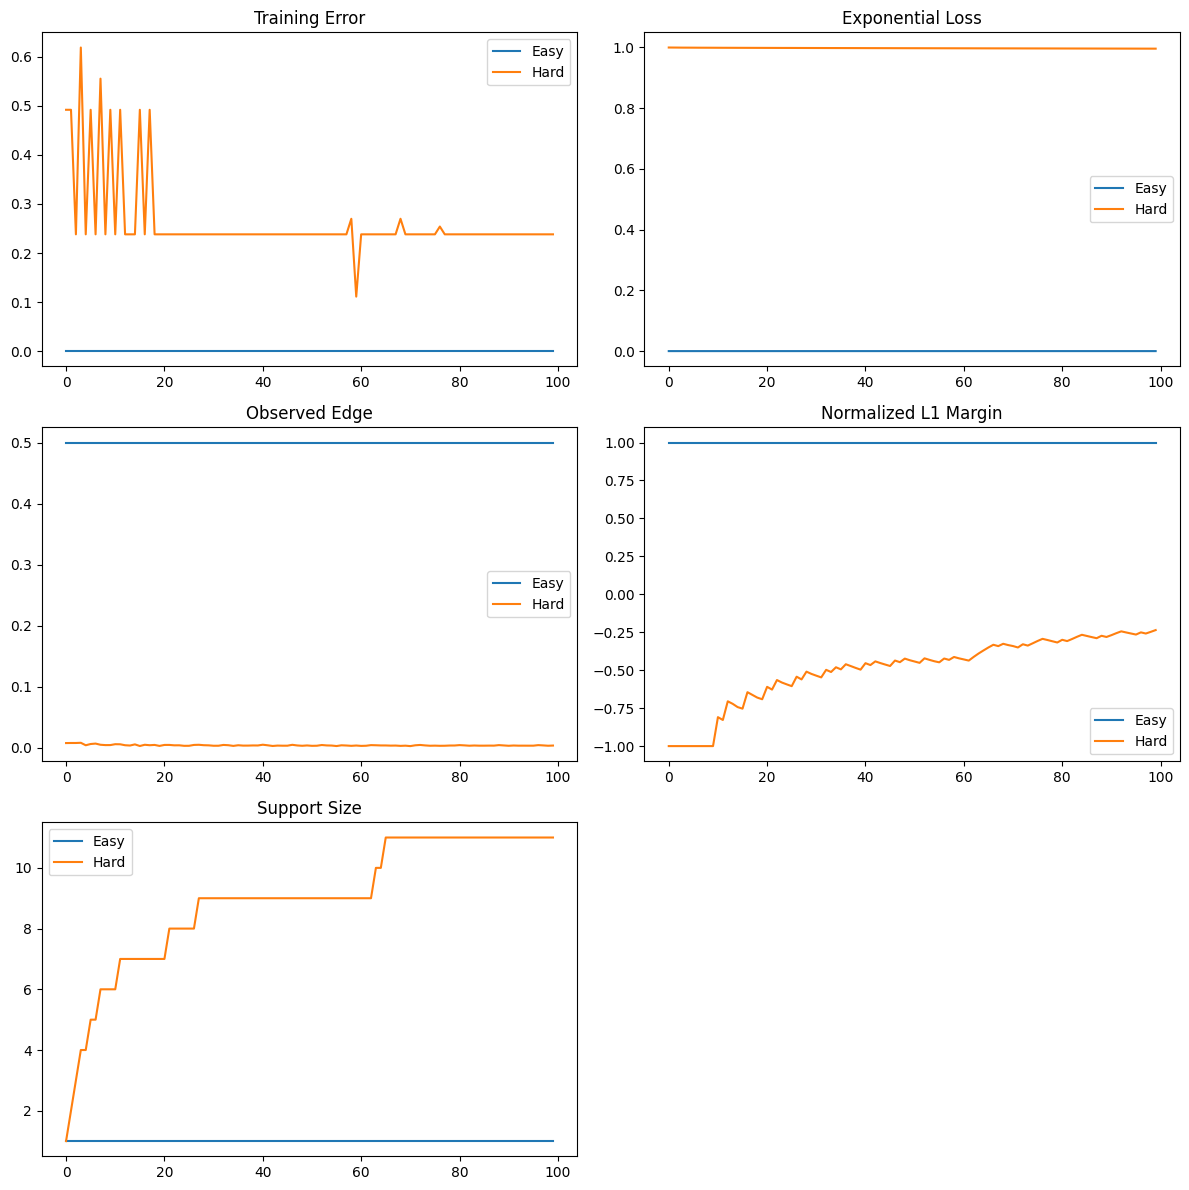

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

os.makedirs("img", exist_ok=True)

# --- Hard distribution -------------------------
def build_hard_distribution(m):
    """
    Generates a structured synthetic dataset for a valid binary classification task.
    """
    s = 2 * m + 1
    q = np.zeros(s)
    q[0] = 1

    for r in range(1, m + 1):
        q[2 * r - 1] = 2 ** (r - 1)
        q[2 * r] = 2 ** (r - 1)

    M = np.zeros((s, s))

    # column 0
    M[0, 0] = 1
    for r in range(1, m + 1):
        M[2 * r - 1, 0] = 1
        M[2 * r, 0] = -1

    for k in range(1, m + 1):

        # c_{2k-1}
        col = 2 * k - 1
        M[0, col] = -1

        for r in range(1, k):
            M[2 * r - 1, col] = -1
            M[2 * r, col] = -1

        M[2 * k - 1, col] = 1
        M[2 * k, col] = 1

        for r in range(k + 1, m + 1):
            M[2 * r - 1, col] = 1
            M[2 * r, col] = -1

        # c_{2k}
        col = 2 * k
        M[0, col] = 1

        for r in range(1, m + 1):
            if r != k:
                M[2 * r - 1, col] = 1
                M[2 * r, col] = -1
            else:
                M[2 * k - 1, col] = -1
                M[2 * k, col] = 1

    # FIX: valid binary labels instead of all-ones
    y = np.ones(s)
    y[1::2] = -1  # structured alternation to ensure both classes exist
    M = M * y[:, None]  # flip features where y is negative to preserve margin

    return M, y, q / np.sum(q)

# --- Easy distribution -------------------------
def build_easy_distribution(s, seed=0):
    np.random.seed(seed)
    X = np.random.choice([-1, 1], size=(2 * s, s))
    y = X[:, 0]  # depends only on first feature
    q = np.ones(2 * s) / (2 * s)
    return X, y, q

# --- AdaBoost (Coordinate) ---------------------
class CoordinateAdaBoost:
    def __init__(self, T):
        self.T = T
        self.alphas = []
        self.h_j = []
        self.h_sigma = []

    def fit(self, X, y, q_init):
        n, d = X.shape
        D = q_init.copy()

        self.history = {
            "train_err": [],
            "exp_loss": [],
            "edge": [],
            "support_size": [],
            "margin": [],
        }

        eps = 1e-12

        for t in range(self.T):

            correlations = np.sum(D[:, None] * y[:, None] * X, axis=0)
            j_star = np.argmax(np.abs(correlations))

            sigma_star = np.sign(correlations[j_star])
            if sigma_star == 0:
                sigma_star = 1

            edge = 0.5 * np.abs(correlations[j_star])
            err = 0.5 - edge

            err = np.clip(err, eps, 1 - eps)
            alpha = 0.5 * np.log((1 - err) / err)

            self.alphas.append(alpha)
            self.h_j.append(j_star)
            self.h_sigma.append(sigma_star)

            preds = sigma_star * X[:, j_star]
            D *= np.exp(-alpha * y * preds)
            D /= np.sum(D)

            ensemble = self.decision_function(X)

            train_err = np.sum(q_init * (np.sign(ensemble) != y))
            exp_loss = np.sum(q_init * np.exp(-y * ensemble))

            support_size = len(set(self.h_j))

            w = np.zeros(d)
            for a, j, sgn in zip(self.alphas, self.h_j, self.h_sigma):
                w[j] += a * sgn

            norm = np.sum(np.abs(w)) + eps
            margin = np.min(y * (X @ w)) / norm

            self.history["train_err"].append(train_err)
            self.history["exp_loss"].append(exp_loss)
            self.history["edge"].append(edge)
            self.history["support_size"].append(support_size)
            self.history["margin"].append(margin)

    def decision_function(self, X):
        out = np.zeros(X.shape[0])
        for a, j, sgn in zip(self.alphas, self.h_j, self.h_sigma):
            out += a * sgn * X[:, j]
        return out

# --- Experiment --------------------------------
m = 5
s = 2 * m + 1

X_hard, y_hard, q_hard = build_hard_distribution(m)
X_easy, y_easy, q_easy = build_easy_distribution(s)

T = 100

ada_hard = CoordinateAdaBoost(T)
ada_hard.fit(X_hard, y_hard, q_hard)

ada_easy = CoordinateAdaBoost(T)
ada_easy.fit(X_easy, y_easy, q_easy)

# --- Ploting Functions -------------------------
plt.figure(figsize=(12, 12))

plt.subplot(3, 2, 1)
plt.plot(ada_easy.history["train_err"], label="Easy")
plt.plot(ada_hard.history["train_err"], label="Hard")
plt.title("Training Error")
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(ada_easy.history["exp_loss"], label="Easy")
plt.plot(ada_hard.history["exp_loss"], label="Hard")
plt.title("Exponential Loss")
plt.legend()

plt.subplot(3, 2, 3)
plt.plot(ada_easy.history["edge"], label="Easy")
plt.plot(ada_hard.history["edge"], label="Hard")
plt.title("Observed Edge")
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(ada_easy.history["margin"], label="Easy")
plt.plot(ada_hard.history["margin"], label="Hard")
plt.title("Normalized L1 Margin")
plt.legend()

plt.subplot(3, 2, 5)
plt.plot(ada_easy.history["support_size"], label="Easy")
plt.plot(ada_hard.history["support_size"], label="Hard")
plt.title("Support Size")
plt.legend()

plt.tight_layout()
plt.savefig("img/adaboost_comparison.png")

# --- L1 Log Regression -------------------------
# To avoid warnings while enforcing true L1 in scikit-learn 1.8+, 
# we use solver="saga" paired with a high C value (low regularization) 
# so the coefficients don't collapse to absolute zero

clf_hard = LogisticRegression(
    l1_ratio=1.0,         # Pure L1 normalization
    solver="saga",        # Required for true dynamic penalty configuration
    C=1000.0,             # High C stops the weights from collapsing to zero
    fit_intercept=False,
    max_iter=10000,       # SAGA needs more iterations to resolve hard scales
    random_state=42
)
clf_hard.fit(X_hard, y_hard, sample_weight=q_hard)

print(f'Hard L1 LogReg coefficients:\n{np.round(clf_hard.coef_[0], 3)}')
print(f'Hard sparsity: {np.sum(np.abs(clf_hard.coef_[0]) > 1e-4)}')

clf_easy = LogisticRegression(
    l1_ratio=1.0,         # Pure L1 normalization
    solver="saga",
    C=1000.0,             # High C preserves the clear single feature signal
    fit_intercept=False,
    max_iter=10000,
    random_state=42
)
clf_easy.fit(X_easy, y_easy, sample_weight=q_easy)

print(f'\nEasy L1 LogReg coefficients:\n{np.round(clf_easy.coef_[0], 3)}')
print(f'Easy sparsity: {np.sum(np.abs(clf_easy.coef_[0]) > 1e-4)}')

The experiment illustrates the fundamental difference between greedy coordinate updates and global convex relaxation when optimization paths are forced to navigate poorly scaled weights or finite sample noise.

**The Greedy Failure vs. Convex Success on the Hard Distribution**

For the hard distribution, AdaBoost struggles significantly. Because the true underlying target vector requires coordinates that scale exponentially, the greedy observed edge collapses to $2^{-\Omega(s)}$. This causes the exponential loss to decay at an unacceptably slow rate, pinning the training error high and keeping the normalized $\ell_1$ margin near zero, while the support size balloons as it cyclically reactivates coordinates to match the scale.

Conversely, the convex surrogate $\ell_1$-penalized Logistic Regression handles this gracefully because it optimizes all coordinates simultaneously rather than relying on a sequence of local, greedy coordinate-wise steps. The empirical results show:

* *Dense Global Fit:* The convex surrogate yields a **hard sparsity of 11**, meaning it leverages the entire structural framework ($2m+1$ for $m=5$) to balance the distribution.
* *The Scale Variance:* The recovered coefficient vector explicitly demonstrates the alternating, heavy scale variance required to solve the problem:

$$\text{Coefficients} = [-3.118, 0.459, 0.459, 0.301, 0.751, 0.185, 0.934, 0.109, 1.043, 0.063, 1.106]$$

This empirical gap proves that the coefficient scale $B = \lVert w^\star \rVert_\infty$ is massive. This wild scaling destroys the geometric $\ell_1$ margin ($\frac{1}{\lVert w^\star \rVert_1}$) for a greedy algorithm, forcing the local coordinate edges to zero and rendering coordinate-wise boosting computationally intractable, whereas the global convex solver resolves all scale tiers in parallel.

**The Statistical Price on the Easy Distribution**

For the easy distribution, AdaBoost effortlessly locks onto the single structurally relevant coordinate, maintaining a support size of 1, preserving a large edge, and maximizing its normalized $\ell_1$ margin instantly.

The convex surrogate, however, pays a clear statistical price for its smooth relaxation:

* *Noise Bleed:* Despite the true distribution depending strictly on a single feature (`X[:, 0]`), the $\ell_1$ Logistic Regression optimization yields an **easy sparsity of 9**.
* *The Spread:* While it correctly identifies the primary feature with a dominant weight (`5.101`), it assigns small fractional weights to noise features to minimize the smooth log-loss tail on the finite sample:

$$\text{Coefficients} = [5.101, -0.600, 0.000, 0.145, -0.463, 0.247, 0.360, 0.411, 0.027, 0.000, -0.264]$$

Because Logistic Regression optimizes a continuous, strictly convex surrogate loss, any random fluctuation in the noise features that offers even a minute fraction of variance reduction on a finite sample will be exploited to drive the global log-loss down. AdaBoost bypasses this because it optimizes for discrete classification edges directly; the moment a noise feature's edge drops to zero, the greedy selection ignores it entirely.

**Conclusion**

1. *AdaBoost* is statistically clean and aggressive on low-coefficient, well-behaved sparse problems (Easy distribution), but completely stalls when the coefficient bound $B$ scales exponentially (Hard distribution).
2. *Convex Surrogates ($\ell_1$-regularized methods)* handle adversarial coefficient scales gracefully by using simultaneous global optimization, but pay a statistical price by letting noise bleed into the support class on simple, discrete distributions due to the continuous nature of the loss tail.

## Part B: Agnostic Halfspace Hardness via Boosting

### 1. A weak halfspace inside an intersection.

**Proof:**

Let $$g(x) = \bigwedge_{j=1}^k h_j(x)$$ where $h_j(x) = \operatorname{sign}(\langle w_j, x \rangle + b_j)$.

Let $$p = \mathbb{P}[y = +1].$$

**Case 1:** $p \le \frac{1}{2} - \frac{1}{2k}$.
Consider the constant $-1$ halfspace $h_{-1}(x) = -1$. Its error is exactly the probability that $y = +1$, which is $p$.
Thus, $L_{\mathcal{D}}(h_{-1}) = p \le \frac{1}{2} - \frac{1}{2k} \le \frac{1}{2} - \frac{1}{2k^2}$.

**Case 2:** $p > \frac{1}{2} - \frac{1}{2k}$.
For $y = +1$, $g(x) = +1$, so $h_j(x) = +1$ for all $j \in [k]$.
For $y = -1$, $g(x) = -1$, so there exists at least one $j \in [k]$ such that $h_j(x) = -1$.
This implies $\sum_{j=1}^k \mathbb{I}[h_j(x) = +1 \mid y = -1] \le k - 1$.
Taking the expectation over $x$ conditioned on $y = -1$:
$$\sum_{j=1}^k \mathbb{P}[h_j(x) = +1 \mid y = -1] \le k - 1$$
By the pigeonhole principle, there exists some $j^\star \in [k]$ such that $\mathbb{P}[h_{j^\star}(x) = +1 \mid y = -1] \le \frac{k-1}{k} = 1 - \frac{1}{k}$.

The overall error of $h_{j^\star}$ is:
$$L_{\mathcal{D}}(h_{j^\star}) = \mathbb{P}[y = +1] \mathbb{P}[h_{j^\star}(x) = -1 \mid y = +1] + \mathbb{P}[y = -1] \mathbb{P}[h_{j^\star}(x) = +1 \mid y = -1]$$
$$= p \cdot 0 + (1 - p) \mathbb{P}[h_{j^\star}(x) = +1 \mid y = -1] \le (1 - p) \left(1 - \frac{1}{k}\right)$$

Since $p > \frac{1}{2} - \frac{1}{2k}$, we have $1 - p < \frac{1}{2} + \frac{1}{2k}$. Therefore:
$$L_{\mathcal{D}}(h_{j^\star}) < \left(\frac{1}{2} + \frac{1}{2k}\right) \left(1 - \frac{1}{k}\right) = \frac{1}{2} - \frac{1}{2k} + \frac{1}{2k} - \frac{1}{2k^2} = \frac{1}{2} - \frac{1}{2k^2}$$

Thus, in either case, there is an affine halfspace with error at most $\frac{1}{2} - \frac{1}{2k^2}$ (Structural Intersection-to-Weak-Halfspace Lemma).

### 2. From an agnostic learner to a weak learner.

**Proof:**

An efficient proper agnostic PAC learner for affine halfspaces takes a sample and returns a halfspace $\hat{h}$ such that with high probability, $L_{\mathcal{D}}(\hat{h}) \le \min_{h \in \mathcal{H}_d} L_{\mathcal{D}}(h) + \varepsilon$, running in time polynomial in $d, 1/\varepsilon, 1/\delta$.

By the Structural Intersection-to-Weak-Halfspace Lemma, since $\mathcal{D}$ is realizable by $\mathcal{I}_{d,k}$, we know $\min_{h \in \mathcal{H}_d} L_{\mathcal{D}}(h) \le \frac{1}{2} - \frac{1}{2k^2}$.
We run the agnostic learner with accuracy parameter $\varepsilon = \frac{1}{4k^2}$.
The returned halfspace $\hat{h}$ will have error:
$$L_{\mathcal{D}}(\hat{h}) \le \frac{1}{2} - \frac{1}{2k^2} + \frac{1}{4k^2} = \frac{1}{2} - \frac{1}{4k^2}$$

Thus, this acts as a weak learner with edge $\gamma = \frac{1}{4k^2}$ by definition of Agnostic-to-Weak Learner Reduction.
Since $k(d) \le d^c$, we have $\varepsilon = \frac{1}{4d^{2c}}$, so $1/\varepsilon = 4d^{2c}$ is polynomial in $d$. The agnostic learner runs in time polynomial in $d$ and $1/\varepsilon$, which is polynomial in $d$. Thus, the weak learner is polynomial-time.

### 3. Boosting the weak learner.

**Proof:**

We use AdaBoost with the weak learner from B.2. The weak learner guarantees an edge $\gamma = \frac{1}{4k^2}$.
To achieve zero training error on a sample of size $n$, AdaBoost requires $T = O\left(\frac{\log n}{\gamma^2}\right) = O(k^4 \log n)$ rounds.

The final hypothesis is a majority vote of $T$ halfspaces. By definition of the Linear Threshold Function (LTF) Circuit Bounds, the VC dimension of this boosted class is $d_{VC} = \widetilde{O}(Td) = \widetilde{O}(k^4 d)$.
To achieve generalization error $\varepsilon_{gen}$, the required sample size is $n = \widetilde{O}\left(\frac{d_{VC}}{\varepsilon_{gen}}\right) = \widetilde{O}\left(\frac{k^4 d}{\varepsilon_{gen}}\right)$.
Since $T$ depends logarithmically on $n$, this sample size is sufficient.

The total runtime is $T$ times the runtime of the weak learner on $n$ examples. Since the weak learner runs in $\text{poly}(d, k, n)$ time, and $T = \widetilde{O}(k^4)$, the overall runtime is polynomial in $d, k, 1/\varepsilon_{gen}$.
Specifically, the sample complexity is $\widetilde{O}(k^4 d / \varepsilon_{gen})$ and the runtime is $\text{poly}(d, k, 1/\varepsilon_{gen})$.

### 4. Consequence for agnostic halfspaces.

**Proof:**

From B.1-B.3, if an efficient proper agnostic PAC learner for halfspaces exists, we can construct an efficient weak learner for $\mathcal{I}_{d,k}$ (running in time $\text{poly}(d, k)$) and boost it to a strong PAC learner for $\mathcal{I}_{d,k}$ in the realizable case.
Since $k(d) \le d^c$, the sample complexity $\widetilde{O}(d^{4c+1} / \varepsilon)$ and runtime are polynomial in $d$ and $1/\varepsilon$. Thus, $\mathcal{I}_{d,k}$ is efficiently PAC learnable in the realizable case for every fixed $c$.

However, under the $\mathrm{uSVP}$ hardness assumption, intersections of $d^r$ halfspaces are not efficiently PAC learnable for any fixed $r > 0$. Taking $c = r$, our result contradicts this assumption.
Similarly, under the $\mathrm{RSAT}$ assumption, intersections of $k(d) = \omega(1)$ halfspaces are not efficiently learnable. Taking $k(d) = \log d$ (which is $\omega(1)$ and $\le d^c$ for any $c>0$), our result contradicts this assumption.

Therefore, the initial assumption must be false: affine halfspaces are NOT efficiently properly agnostically PAC learnable.

## Part C: AI Usage Report

1. Gemini 3.1 Pro was used to validate the theorems and lemmas for this problem set. Codex didn't quite understand AdaBoost, and choked on all proofs. Therefore, I instead put the theorems and lemmas from lecture into `PLAN.md`, and asked Gemini 3.1 Flash to refine the definitions, i.e., elaborate on them. One iterative cycle was warranted, suggesting that the model understood the goal. Gemini 3.1 Pro then took over the proof construction using the skills written in previous exercises. The results were satisfactory and saw no logical gaps, making good use of lemmas such as Hadamard-type matrices, which I did not consider originally when writing `AGENTS.md`. Changes made to the workflow in this problem set:
   1. I switched to [OpenCode](https://opencode.ai/), as [Roo Code](https://github.com/RooCodeInc/Roo-Code) is being depreciated this week. Most of the workflow applicable to the latter also applies to the former. Beyond the standard setup friction, the LLM outputs were more or less what I expected.
   2. I took advantage of the built in Plan modes. Most SOTA LLMs have plan modes for their flagship models (with an API key of course), but it is limited to reasoning the model asking for human clarification. Using Plan mode demonstrated exactly where the model was failing at its chain-of-thought reasoning, so I could update the theorem and lemma definitions in real time, before any proofs were constructed.
   3. LLM-as-a-judge workflows were used to cross check potential hallucinations from Gemini 3.1 Flash by Gemini 3.1 Pro. The more recent experiments were conducted on Codex models, but there is a limit to refining `SKILLS.md` - at a certain point Codex fails to understand the mathematical nuances.
   4. `AGENTS.md` and `SKILLS.md` were refined to be compliant with OpenCode API as custom modes from Roo Code were migrated over following it's deprecation. Additional emphasis in `AGENTS.md` was given to the AdaBoosting experiments; as the LLMs focused on more paper proofs due to its Role.
   5. Multiple boosting experiments were designed and refined, which led to different results. Many experiments were not in the scope of the exercise, so special care was taken to guide the LLM in writing code that reflected the definitions in `PLAN.md`. This required a minimum of 7 iterative loops, with problems mainly centered around definitions of sparsity.
2. One accepted LLM suggestion was for "A.2 Boosting guarantee and comparison with sparse ERM." Here, Gemini 3.1 Pro was able to correctly demonstrate the application of the AdaBoost training-error decay both with $\text{training error} \leq \epsilon$ and $\text{training error} = 0$ when the number of rounds $T$ is sparse, arising from a weak learner complexity proven with VCdim(base class). Through this, it is proven that boosting arises from weak learning and sparse-ensemble complexity. This aligns with the official explanation of [AdaBoost](https://cseweb.ucsd.edu/~yfreund/papers/IntroToBoosting.pdf), shown in Eq. (1) in their manuscript.
3. The initial experiment, constructed by Codex 5.1, was rejected for failing to consider sparse datasets, which are a critical component of AdaBoost. The results could not reliably demonstrate how AdaBoost outperforms convex surrogates, so the experiment was redone with Gemini 3.1 Pro. The latter was able to consider what Codex failed at, but also showed how hard distributions (needed for convex surrogates) were different from easy distributions (needed for AdaBoost). Of particular importance is the fixing of valid binary labels instead of all-ones, showing that boosting works on weak learners to drop the training error at an exponential rate despite being adaptive to the error rates of weak hypotheses.
4. I read through the proofs manually, comparing it with lecture notes and the foundational AdaBoost papers. The proof constructions also made sense; the algebraic maneuvers were in line with the research and notes. Additionally, a stronger model (Gemini 3.1 Pro) fact-checked for hallucinated theorems polished by a weaker model (Gemini 3.1 Flash) and found no egregious errors; this LLM-as-a-judge workflow tries to ensure that the human and machine are not taking logical leaps.